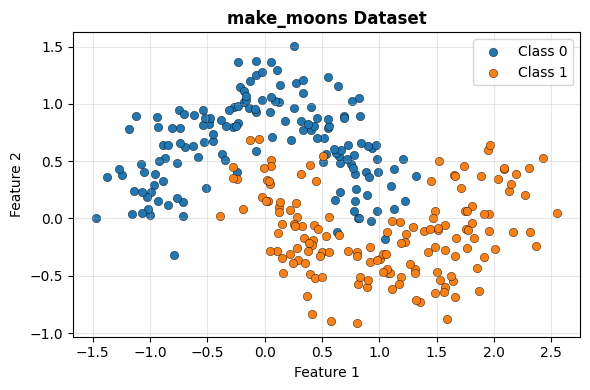

Train Accuracy: 0.9714
Test Accuracy:  0.9778


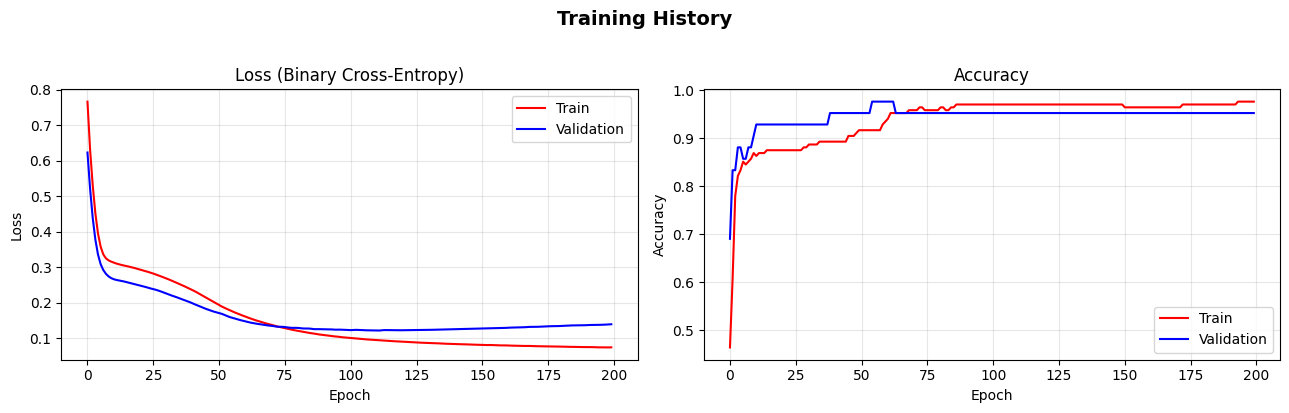

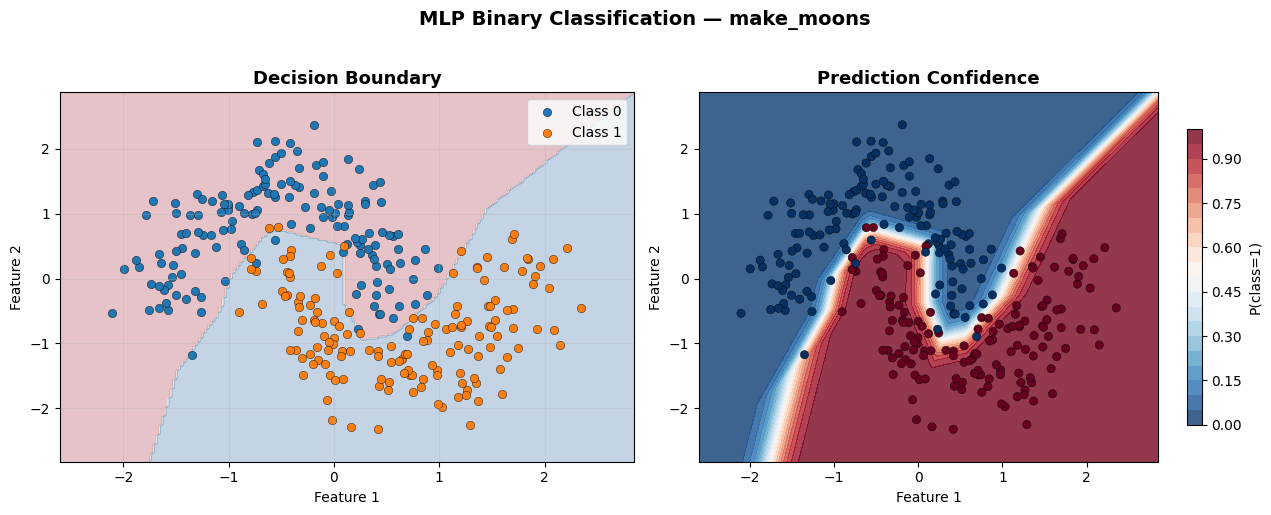

In [1]:
# ==============================
# Week 4 - MLP Binary Classification
# Non-linear Decision Boundary (make_moons)
# ==============================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)

# ==============================
# 1. Generate & Visualize Data
# ==============================
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(6, 4))
for label in [0, 1]:
    plt.scatter(X[y==label, 0], X[y==label, 1], label=f'Class {label}', edgecolors='k', linewidth=0.3)
plt.title('make_moons Dataset', fontweight='bold')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ==============================
# 2. Preprocessing
# ==============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_all = scaler.transform(X)

# ==============================
# 3. Build & Train
# ==============================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=200, validation_split=0.2, verbose=0)

# ==============================
# 4. Results
# ==============================
loss, acc = model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {acc:.4f}")

# --- Loss & Accuracy ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history.history['loss'], 'r-', label='Train')
ax1.plot(history.history['val_loss'], 'b-', label='Validation')
ax1.set(title='Loss (Binary Cross-Entropy)', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], 'r-', label='Train')
ax2.plot(history.history['val_accuracy'], 'b-', label='Validation')
ax2.set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle('Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Decision Boundary ---
xx, yy = np.meshgrid(np.linspace(X_all[:,0].min()-0.5, X_all[:,0].max()+0.5, 200),
                      np.linspace(X_all[:,1].min()-0.5, X_all[:,1].max()+0.5, 200))
Z = (model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5).astype(int).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
for label in [0, 1]:
    ax1.scatter(X_all[y==label, 0], X_all[y==label, 1], label=f'Class {label}', edgecolors='k', linewidth=0.3)
ax1.set_title('Decision Boundary', fontsize=13, fontweight='bold')
ax1.set_xlabel('Feature 1'); ax1.set_ylabel('Feature 2')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Prediction Confidence
Z_prob = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0).reshape(xx.shape)
cf = ax2.contourf(xx, yy, Z_prob, levels=20, cmap='RdBu_r', alpha=0.8)
ax2.scatter(X_all[:, 0], X_all[:, 1], c=y, cmap='RdBu_r', edgecolors='k', linewidth=0.3)
ax2.set_title('Prediction Confidence', fontsize=13, fontweight='bold')
ax2.set_xlabel('Feature 1'); ax2.set_ylabel('Feature 2')
fig.colorbar(cf, ax=ax2, shrink=0.8, label='P(class=1)')

fig.suptitle('MLP Binary Classification — make_moons', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()